In [1]:
import os, sys
from pathlib import Path
import numpy as np
from scipy import stats
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import importlib

import torch
from torch.utils.data import DataLoader

import torch.nn as nn #?
from torch.functional import F #?
import torch.distributions as dist #?
from torch.utils.data import DataLoader, TensorDataset, random_split #?
import torchvision #?

import zuko

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor, TQDMProgressBar

sys.path.append('../') 
from utils import datasets
import utils.resnet_cond as resnet
import utils.lightning_flows as LFlows
from utils import lightning_flows_density as LFlowsDensity


/n/home11/aakhmetzhanova/.conda/envs/ccl-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: aakhmetzhanova. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /n/home11/aakhmetzhanova/.netrc
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or runnin

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Main code

In [3]:
field      = 'Mgas'
results_dir = Path("results/")

params_S = np.load(results_dir / f'{field}_params_SIMBA_LH_test.npy')
params_A = np.load(results_dir / f'{field}_params_Astrid_LH_test.npy')
params_I = np.load(results_dir / f'{field}_params_IllustrisTNG_LH_test.npy')

params_S_CV = np.load(results_dir / f'{field}_params_SIMBA_CV.npy')
params_A_CV = np.load(results_dir / f'{field}_params_Astrid_CV.npy')
params_I_CV = np.load(results_dir / f'{field}_params_IllustrisTNG_CV.npy')

###############

evidence_S = np.load(results_dir / f'{field}_log_evidence_SIMBA_LH_test.npy')
evidence_A = np.load(results_dir / f'{field}_log_evidence_Astrid_LH_test.npy')
evidence_I = np.load(results_dir / f'{field}_log_evidence_IllustrisTNG_LH_test.npy')

evidence_S_CV = np.load(results_dir / f'{field}_log_evidence_SIMBA_CV.npy')
evidence_A_CV = np.load(results_dir / f'{field}_log_evidence_Astrid_CV.npy')
evidence_I_CV = np.load(results_dir / f'{field}_log_evidence_IllustrisTNG_CV.npy')

################

In [4]:
k_min, k_max   = 2., 45
k_smooth_array = np.logspace(np.log10(k_min), np.log10(k_max), num=10)
k_smooth_array

array([ 2.        ,  2.826653  ,  3.99498359,  5.64621617,  7.97994694,
       11.27827048, 15.93987854, 22.52825274, 31.83977659, 45.        ])

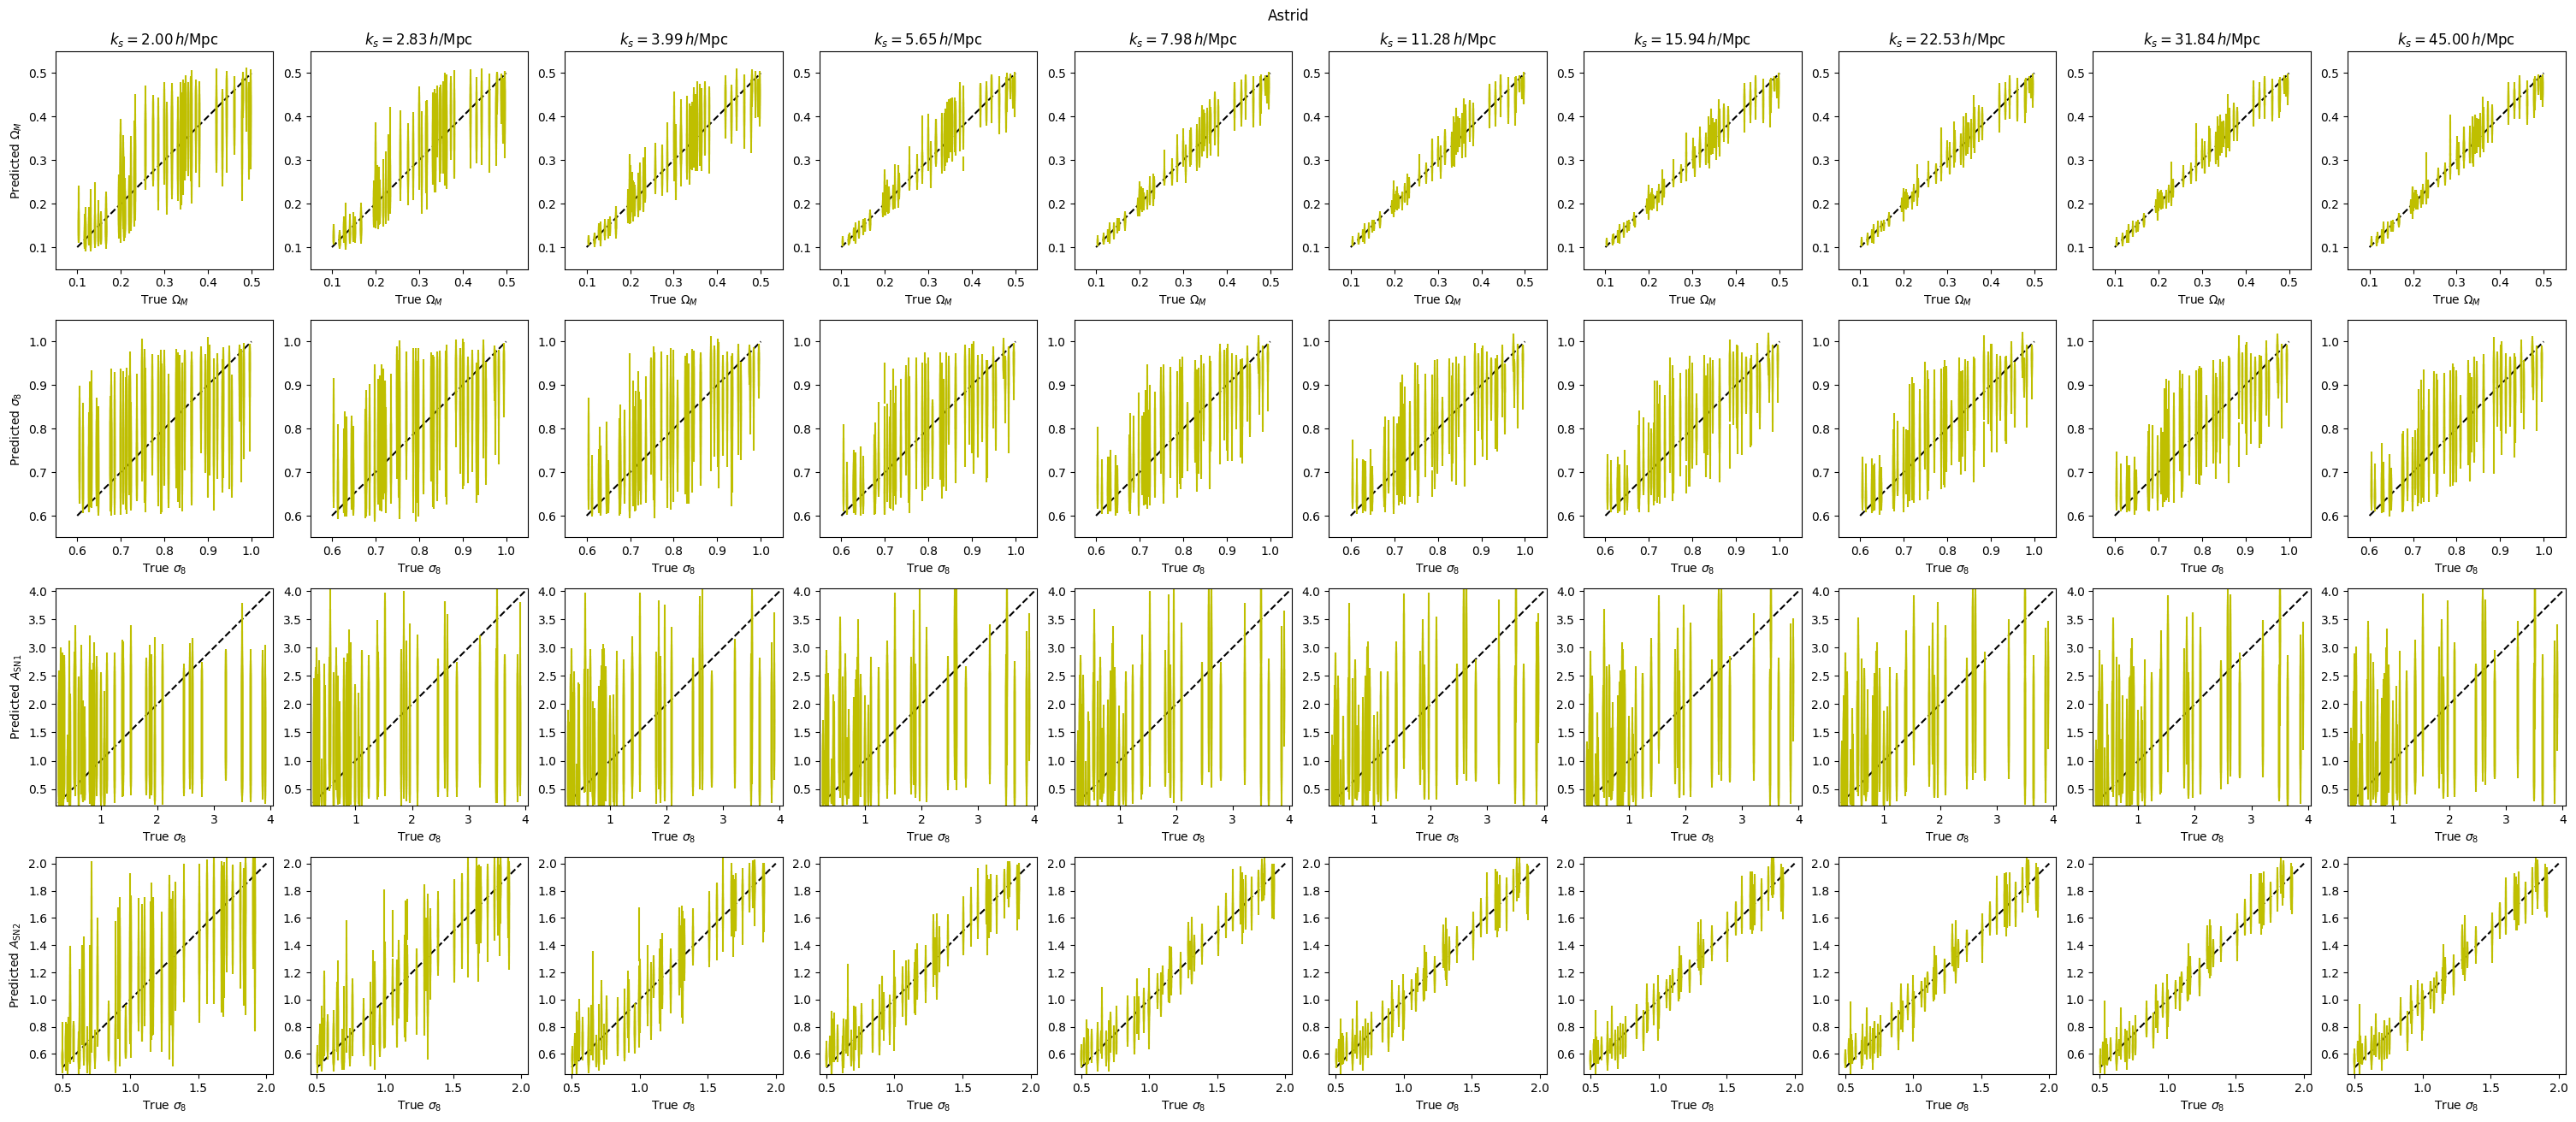

In [5]:
k_indices = np.arange(len(k_smooth_array))
n_rows = 4
n_columns = len(k_indices)
param_idxs = [0, 1, 2, 4]

f, axs = plt.subplots(n_rows, n_columns, figsize=(3*n_columns, 3*n_rows+1), layout="constrained")
plt.suptitle('Astrid')
for n in range(n_rows):
    for i, k_idx in enumerate(k_indices):
        ax = axs[n, i]
        ax.set_aspect('equal')
        if n == 0:
            ax.set_title(fr'$k_s={k_smooth_array[k_idx]:.2f} \, h/$' + 'Mpc')
            ax.plot([0.1, 0.5], [0.1, 0.5], 'k--')
            ax.set_ylim(0.05, 0.55)
            ax.set_xlim(0.05, 0.55)
            if i == 0:
                ax.set_ylabel(r'$\mathrm{Predicted} \,\, \Omega_M$')
            ax.set_xlabel(r'$\mathrm{True} \,\, \Omega_M$')
        elif n == 1:
            ax.plot([0.6, 1.0], [0.6, 1.0], 'k--')
            ax.set_ylim(0.55, 1.05)
            ax.set_xlim(0.55, 1.05)
            if i == 0:
                ax.set_ylabel(r'$\mathrm{Predicted} \,\, \sigma_8$')
            ax.set_xlabel(r'$\mathrm{True} \,\, \sigma_8$')
        elif n == 2:
            ax.plot([0.25, 4.0], [0.25, 4.0], 'k--')
            ax.set_ylim(0.2, 4.05)
            ax.set_xlim(0.2, 4.05)
            if i == 0:
                ax.set_ylabel(r'$\mathrm{Predicted} \,\, A_{\rm SN1}$') 
            ax.set_xlabel(r'$\mathrm{True} \,\, \sigma_8$')
        elif n == 3:
            ax.plot([0.5, 2.0], [0.5, 2.0], 'k--')
            ax.set_ylim(0.45, 2.05)
            ax.set_xlim(0.45, 2.05)
            if i == 0:
                ax.set_ylabel(r'$\mathrm{Predicted} \,\, A_{\rm SN2}$')
            ax.set_xlabel(r'$\mathrm{True} \,\, \sigma_8$')
            
            
        params_true, params_pred, errors_pred = params_A[:, i, :, param_idxs[n]]
        ax.errorbar(params_true, params_pred, errors_pred, linestyle='', c='y')
plt.savefig(f'plots/true_vs_pred_Astrid_{field}.png')          

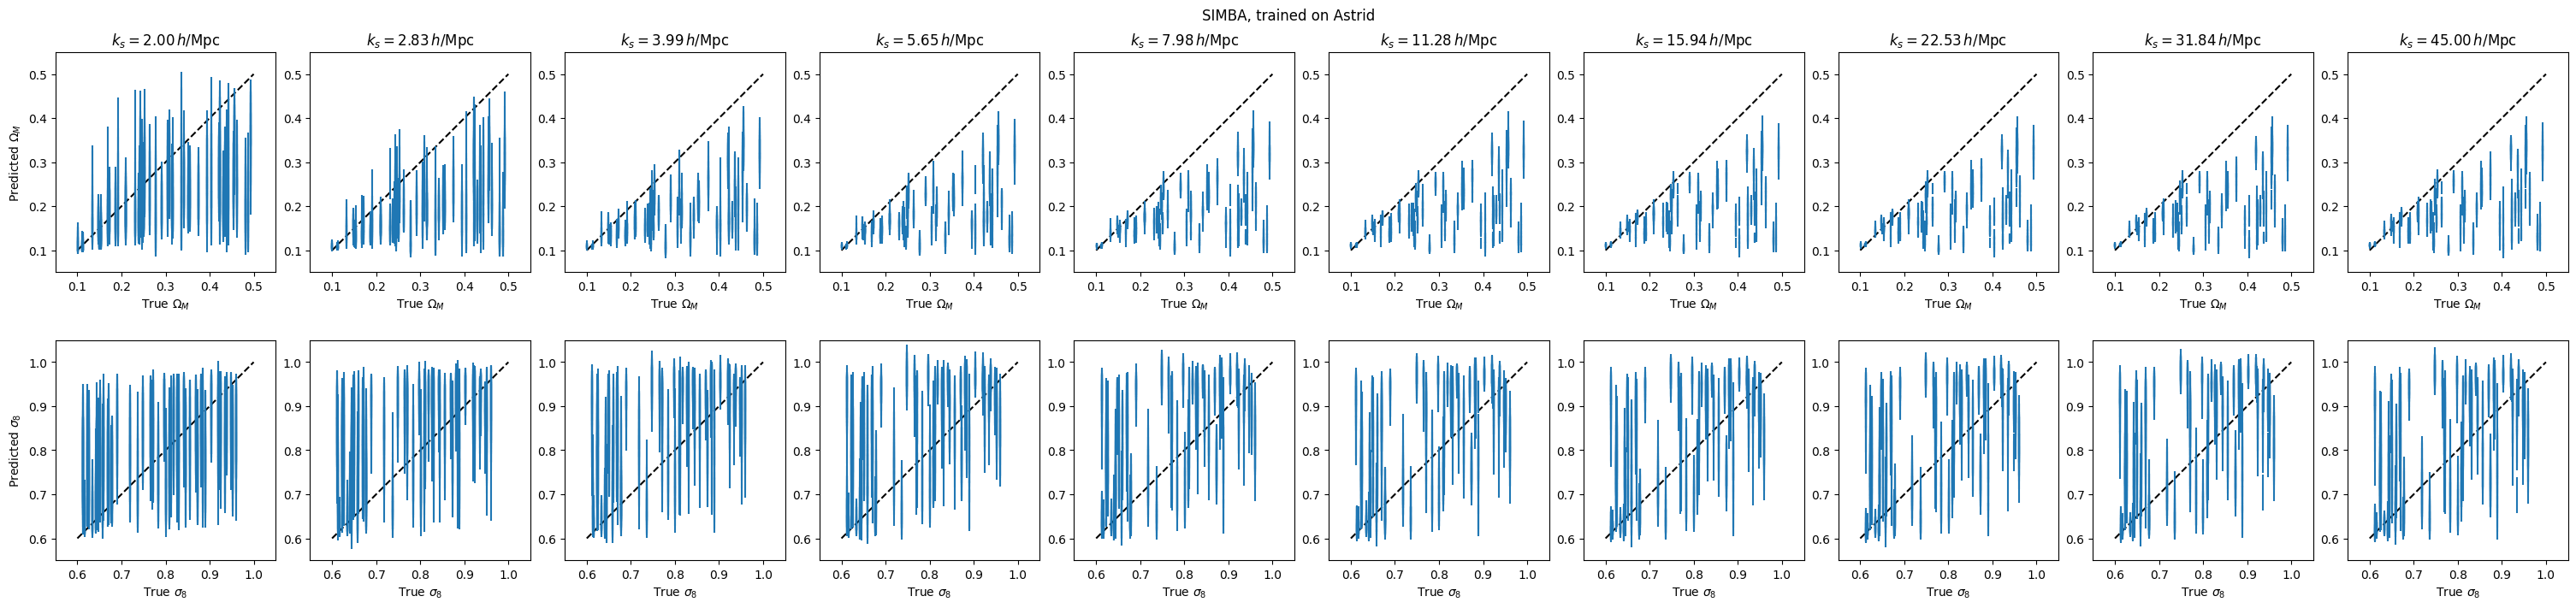

In [6]:
k_indices = np.arange(len(k_smooth_array))
n_rows = 2
n_columns = len(k_indices)

f, axs = plt.subplots(n_rows, n_columns, figsize=(3*n_columns, 3*n_rows+1), layout="constrained")
plt.suptitle('SIMBA, trained on Astrid')
for n in range(n_rows):
    for i, k_idx in enumerate(k_indices):
        ax = axs[n, i]
        ax.set_aspect('equal')
        if n == 0:
            ax.set_title(fr'$k_s={k_smooth_array[k_idx]:.2f} \, h/$' + 'Mpc')
            ax.plot([0.1, 0.5], [0.1, 0.5], 'k--')
            ax.set_ylim(0.05, 0.55)
            ax.set_xlim(0.05, 0.55)
            if i == 0:
                ax.set_ylabel(r'$\mathrm{Predicted} \,\, \Omega_M$')
            ax.set_xlabel(r'$\mathrm{True} \,\, \Omega_M$')
        else:
            ax.plot([0.6, 1.0], [0.6, 1.0], 'k--')
            ax.set_ylim(0.55, 1.05)
            ax.set_xlim(0.55, 1.05)
            if i == 0:
                ax.set_ylabel(r'$\mathrm{Predicted} \,\, \sigma_8$')
            ax.set_xlabel(r'$\mathrm{True} \,\, \sigma_8$')
            
        params_true, params_pred, errors_pred = params_S[:, i, :, n]
        ax.errorbar(params_true, params_pred, errors_pred, linestyle='',)
        
plt.savefig(f'plots/true_vs_pred_SIMBA_{field}.png')        

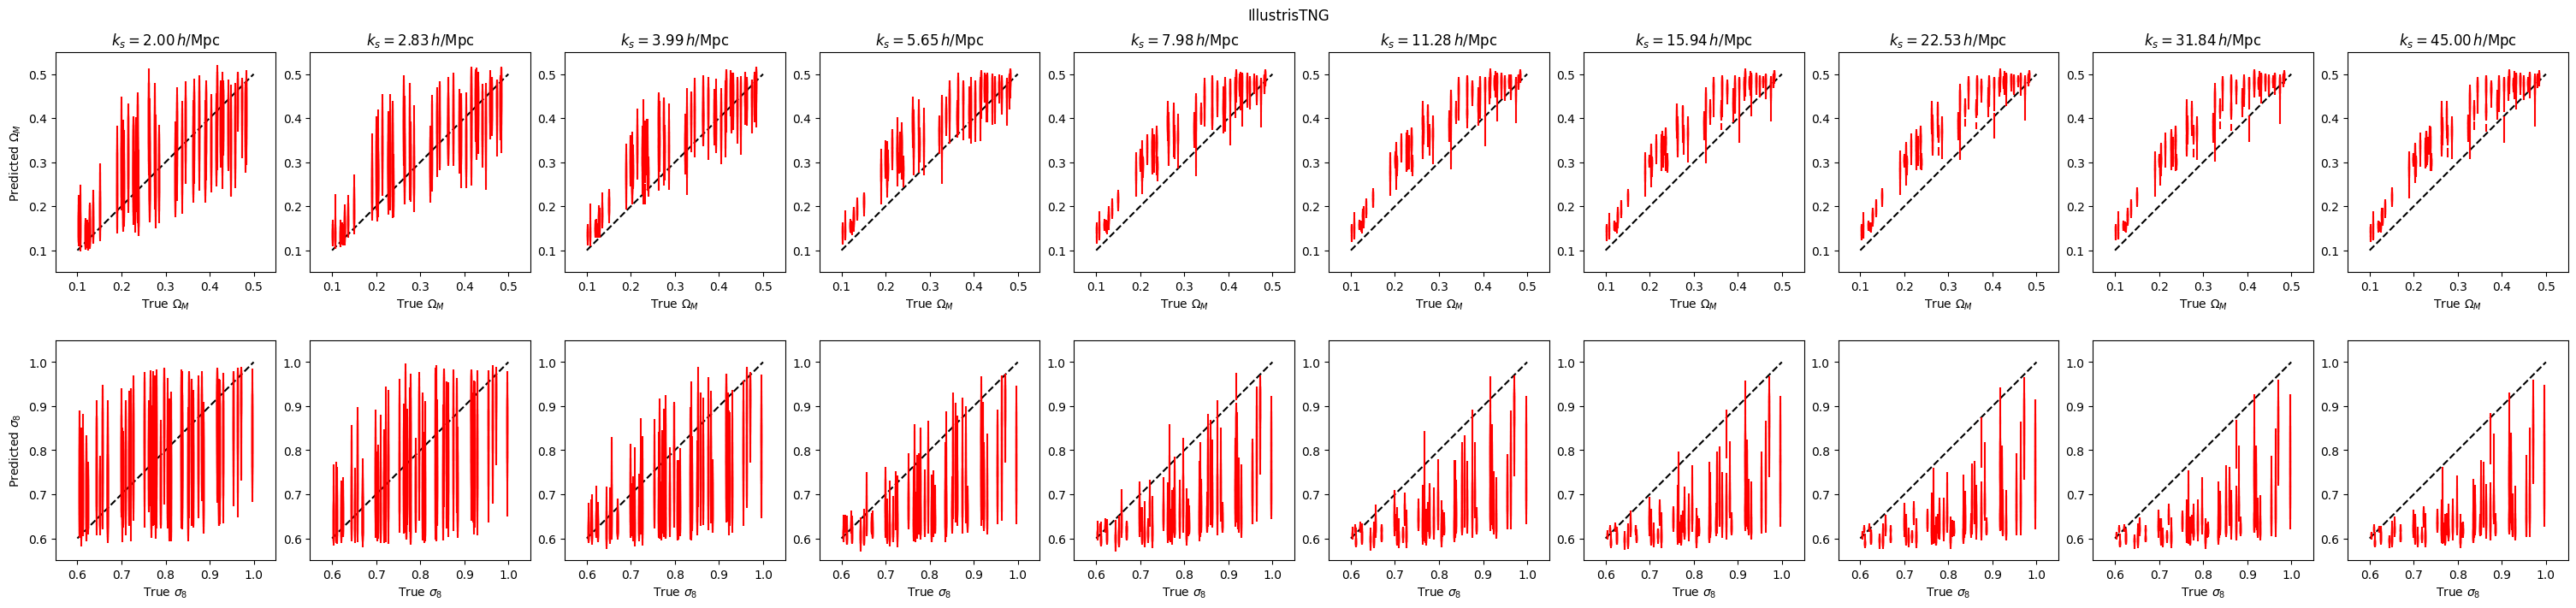

In [7]:
k_indices = np.arange(len(k_smooth_array))
n_rows = 2
n_columns = len(k_indices)

f, axs = plt.subplots(n_rows, n_columns, figsize=(3*n_columns, 3*n_rows+1), layout="constrained")
plt.suptitle('IllustrisTNG')
for n in range(n_rows):
    for i, k_idx in enumerate(k_indices):
        ax = axs[n, i]
        ax.set_aspect('equal')
        if n == 0:
            ax.set_title(fr'$k_s={k_smooth_array[k_idx]:.2f} \, h/$' + 'Mpc')
            ax.plot([0.1, 0.5], [0.1, 0.5], 'k--')
            ax.set_ylim(0.05, 0.55)
            ax.set_xlim(0.05, 0.55)
            if i == 0:
                ax.set_ylabel(r'$\mathrm{Predicted} \,\, \Omega_M$')
            ax.set_xlabel(r'$\mathrm{True} \,\, \Omega_M$')
        else:
            ax.plot([0.6, 1.0], [0.6, 1.0], 'k--')
            ax.set_ylim(0.55, 1.05)
            ax.set_xlim(0.55, 1.05)
            if i == 0:
                ax.set_ylabel(r'$\mathrm{Predicted} \,\, \sigma_8$')
            ax.set_xlabel(r'$\mathrm{True} \,\, \sigma_8$')
            
        params_true, params_pred, errors_pred = params_I[:, i, :, n]
        ax.errorbar(params_true, params_pred, errors_pred, linestyle='', c='r')
        
plt.savefig(f'plots/true_vs_pred_IllustrisTNG_{field}.png')        